The notebook reconstructs the relative risk relationship between otal dairy intake and type-2 diabetes risk from the study: https://doi.org/10.1093/advances/nmac096.

In [ ]:
import random as rand
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
from os import path

from scipy.optimize import fsolve
from scipy.stats import beta
from scipy.optimize import least_squares
import scipy.optimize as optimize
import scipy.stats as stats
from pathlib import Path
from utils import add_code_path
add_code_path()

data_path = Path("data")

Dataset of the total dairy intake and diabetes relative risk

In [ ]:
df_dairy = pd.read_csv(data_path / 'dairy_RR/Dairy_RR_mean.csv')

In [ ]:
df_dairy.head()

,Total dairy,mean_RR,upper_RR,lower_RR
0,3.829787,0.998693,0.999673,0.998693
1,35.744681,0.986275,0.997386,0.976471
2,65.531915,0.975817,0.995098,0.956536
3,88.936170,0.966667,0.993464,0.941503
4,110.212766,0.958824,0.992484,0.926797


In [ ]:
def plot_data(data):
    plt.figure(figsize=(10, 6))

    # Plot the mean RR
    plt.plot(data['Total dairy'], data['mean_RR'], label='Mean RR', color='blue')

    # Plot the confidence intervals
    plt.plot(data['Total dairy'], data['upper_RR'], label='Upper 95% CI', color='blue', linestyle='dashed')
    plt.plot(data['Total dairy'], data['lower_RR'], label='Lower 95% CI', color='blue', linestyle='dashed')

    # Labeling the plot
    plt.xlabel('Total Dairy (g/day)')
    plt.ylabel('Relative Risk of T2DM')
    plt.title('Relative Risk of T2DM vs Total Dairy Intake')
    plt.legend()

    # Show the plot
    plt.grid(True)
    plt.show()

    return

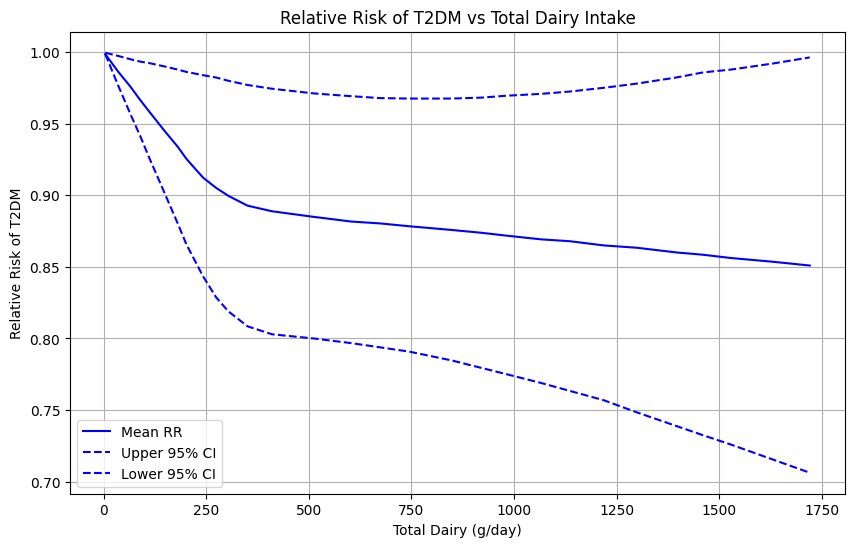

In [ ]:
plot_data(data=df_dairy)

### estimate beta distributions

### MLE

In [ ]:
def beta_mle(x, mean, lower, upper):
    """
    Maximum likelihood estimation function for the beta distribution.
    It minimizes the negative log-likelihood function, taking into account the provided mean and confidence interval bounds.
    """
    # Unpack the parameters
    a, b = x
    # Define the beta distribution with current parameters
    rv = stats.beta(a, b)
    # Calculate the log-likelihood for mean
    ll_mean = np.log(rv.pdf(mean))
    # Calculate the log-likelihood for the confidence interval bounds
    ll_lower = np.log(rv.cdf(lower))
    ll_upper = np.log(rv.cdf(upper))
    # Return the negative log-likelihood
    return -(ll_mean + ll_lower + ll_upper)


def MLE(data):
  # Define initial values for alpha and beta
  initial_guess = [1, 1]

  # Store the estimated parameters
  alpha_params = []
  beta_params = []

  # Loop over the dataset and calculate MLE for each row
  for index, row in data.iterrows():
      mean = row['mean_RR']
      lower = row['lower_RR']
      upper = row['upper_RR']

      # Minimize the negative log-likelihood
      result = optimize.minimize(
          beta_mle,
          initial_guess,
          args=(mean, lower, upper),
          bounds=[(0, None), (0, None)]  # alpha and beta must be > 0
      )

      if result.success:
          # If the optimization was successful, store the parameters
          estimated_alpha, estimated_beta = result.x
          alpha_params.append(estimated_alpha)
          beta_params.append(estimated_beta)
      else:
          # If not successful, append None or raise an error
          alpha_params.append(None)
          beta_params.append(None)
          print(f"Optimization failed for row {index}.")

  return alpha_params, beta_params



In [ ]:
alpha_params, beta_params = MLE(data=df_dairy)

# Add the estimated parameters back to the original dataframe
df_dairy['alpha_MLE'] = alpha_params
df_dairy['beta_MLE'] = beta_params

### plot results


In [ ]:
def sample_beta_distributions(beta_params_df, alpha_col, beta_col, num_samples=1000):
    """
    This function takes samples from beta distributions defined by alpha and beta parameters
    for each 'Total dairy' value and plots the resulting mean and 95% confidence intervals.

    Parameters:
    - beta_params_df: DataFrame with 'Total dairy', 'alpha', and 'beta' columns
    - num_samples: Number of samples to draw from each beta distribution
    """
    means = []
    lower_bounds = []
    upper_bounds = []

    # For each row in the beta parameters dataframe, sample from the beta distribution
    for _, row in beta_params_df.iterrows():
        # Sample from the beta distribution
        samples = np.random.beta(row[alpha_col], row[beta_col], num_samples)

        # Calculate the sample mean and the 95% confidence interval
        sample_mean = np.mean(samples)
        lower_bound, upper_bound = np.percentile(samples, [2.5, 97.5])

        # Append to our lists
        means.append(sample_mean)
        lower_bounds.append(lower_bound)
        upper_bounds.append(upper_bound)

    return means, upper_bounds, lower_bounds

def plot_samples(df, means, upper_bounds, lower_bounds):

    # Now let's plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(df['Total dairy'], means, label='Sampled Mean RR', color='blue')
    plt.plot(df['Total dairy'], lower_bounds, label='95% CI', linestyle='--', color='blue')
    plt.plot(df['Total dairy'], upper_bounds, linestyle='--', color='blue')

    plt.fill_between(df['Total dairy'], lower_bounds, upper_bounds, color='grey', alpha=0.1)

    plt.xlabel('Total Dairy (g/day)')
    plt.ylabel('Relative Risk')
    plt.title('Monte Carlo Simulated Relative Risk and 95% Confidence Intervals')
    plt.legend()
    plt.grid(True)
    plt.savefig('Data/Dairy_RR_estimates/reconstructed_dairy_RR.png', dpi=300)
    plt.show()

    return

In [ ]:
np.random.beta(43.028310, 4.644)

0.9818921571677752

In [ ]:
means_LS, upper_bounds_LS, lower_bounds_LS = sample_beta_distributions(beta_params_df=beta_params_df,
                                                                       alpha_col='alpha',
                                                                       beta_col = 'beta',
                                                                       num_samples=50000)

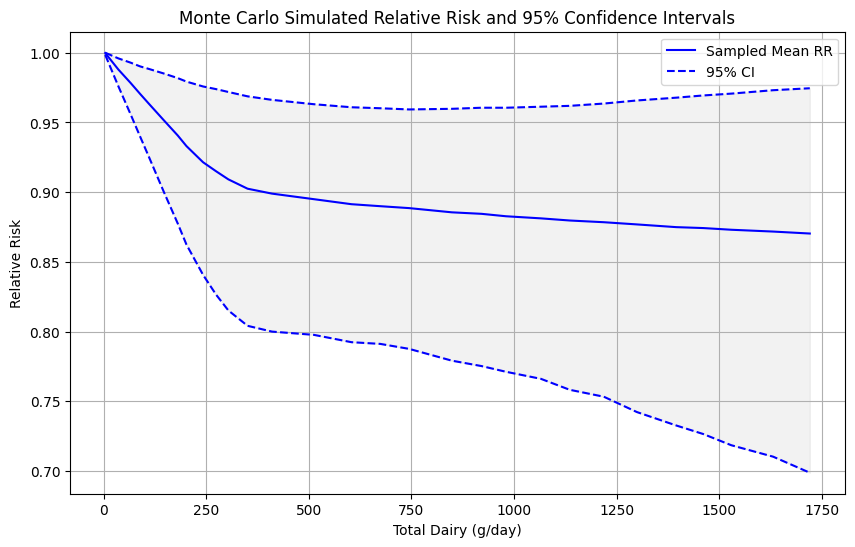

In [ ]:
plot_samples(df=df_dairy, means=means_LS, upper_bounds=upper_bounds_LS, lower_bounds=lower_bounds_LS)

In [ ]:
means_MLE, upper_bounds_MLE, lower_bounds_MLE = sample_beta_distributions(beta_params_df=df_dairy[['alpha_MLE', 'beta_MLE']],
                                                                          alpha_col='alpha_MLE',
                                                                          beta_col = 'beta_MLE',
                                                                          num_samples=50000)

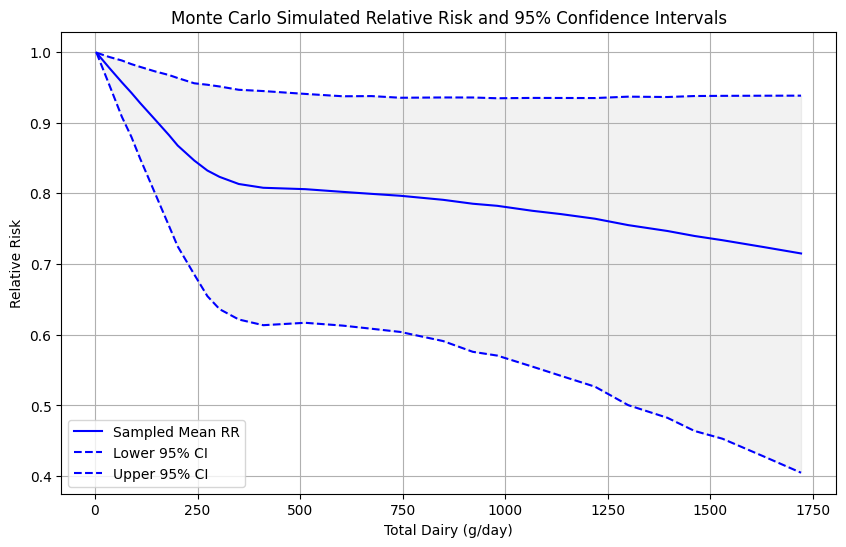

In [ ]:
plot_samples(df=df_dairy, means=means_MLE, upper_bounds=upper_bounds_MLE, lower_bounds=lower_bounds_MLE)

In [ ]:
df_dairy['mean_sample_LS'] = means_LS
df_dairy['mean_sample_MLE'] = means_MLE

In [ ]:
df_dairy[['mean_RR','mean_sample_LS', 'mean_sample_MLE']]

In [ ]:
beta_params_df.to_parquet(data_path / 'beta_samples_dairy.parquet')

In [ ]:
beta_params_df